# Advanced Machine Learning — TP : Transfer Learning

**Full Name:** DJOUAHER Yasmine

**Group :** SID1

**Phase:** Phase 2 — Spatial Adaptation  
**Framework:** TensorFlow / Keras  
**Duration:** 2 hours

---

## Learning Objectives
By the end of this lab you will be able to:
1. Understand and simulate different types of **domain shift** (covariate, label, concept).
2. Separate a CNN into a **backbone** and a **classification head**.
3. Pretrain on a source domain and measure the **domain gap**.
4. Implement and compare **four transfer strategies**: Scratch, Feature Extraction, Gradual Unfreezing, Full Fine-tuning.
5. Apply **discriminative learning rates** (layer-wise LR schedule).
6. Apply transfer learning to a **medical imaging** challenge.

## Lab Rules
- Always use a **validation split** for hyperparameter decisions.
- Do **not** use the test set until the final evaluation.
- Report both accuracy and a short **critical analysis** for each strategy.

| Lab Part |  |
|---|---|
| Part 1 — Domain Shift | Domain Shift: Covariate, Label, Concept Shift |
| Part 2 — Dataset & Domain Creation |  Domain & Task |
| Part 3 — CNN Architecture | Why Transfer Works: Representation Hypothesis |
| Part 4 — Source Pretraining | Model Fine-Tuning|
| Part 5 — Label Budget | Training Data Scarcity |
| Part 6 — Transfer Strategies | Strategy Comparison Table |
| Part 7 — Discriminative LR | Discriminative Learning Rates (Howard & Ruder, 2018) |
| Part 8 — Visualization & Analysis |  |
| Challenge — Medical Imaging | Medical Image Classification |


## Part 0 — Setup & Imports

Run this cell first. All dependencies must be installed before starting.

In [ ]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate as scipy_rotate
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

NUM_CLASSES = 10
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: []


## Part 1 — Domain Shift: Theory & Visualization

The following cell visualizes **covariate shift** — the most common type and the one we address in this lab.


Dataset: (1797, 8, 8), classes: [0 1 2 3 4 5 6 7 8 9]


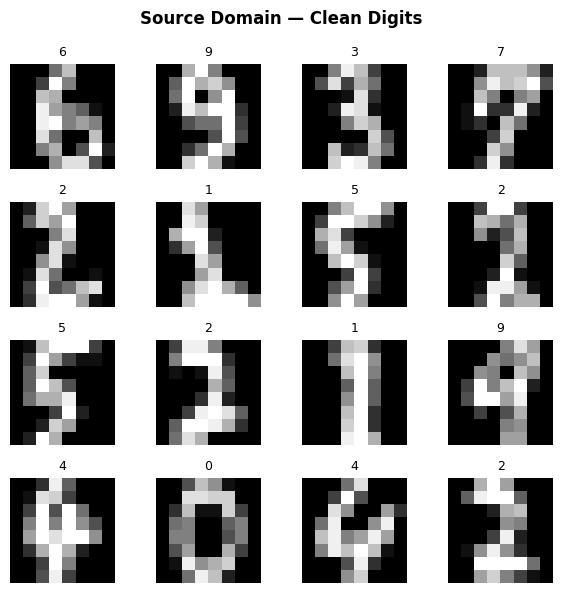

In [ ]:
digits = load_digits()
X = digits.images.astype(np.float32)  # (N, 8, 8)
y = digits.target.astype(np.int64)
X = X / 16.0  # normalize to [0, 1]

print(f"Dataset: {X.shape}, classes: {np.unique(y)}")

def show_grid(images, labels, title, n=16):
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(images), n, replace=False)
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[idx[i]], cmap='gray', vmin=0, vmax=1)
        ax.set_title(str(labels[idx[i]]), fontsize=9)
        ax.axis('off')
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_grid(X, y, "Source Domain — Clean Digits")


## Part 2 — Dataset & Domain Simulation

We simulate a **covariate shift** using the sklearn digits dataset:
- **Source domain:** clean digits (normal acquisition)
- **Target domain:** rotated + noisy digits (degraded sensor)

This mirrors the medical X-ray scenario: a model trained on clean scans fails when deployed with different equipment.


### 2.1 Create the Target Domain

> **TODO:** Implement `make_target_domain`.  
> Apply a rotation of `angle_deg` degrees and add Gaussian noise of std `noise_std`.  
> Clip the result to [0, 1].
>
> **Hints:**  
> - Use `scipy_rotate(img, angle=angle_deg, reshape=False, order=1, mode='constant', cval=0.0)`  
> - Add `np.random.normal(0, noise_std, img.shape)` to each rotated image  
> - Use `np.clip(..., 0.0, 1.0)` at the end


In [ ]:
def make_target_domain(X: np.ndarray, angle_deg: float = 20.0, noise_std: float = 0.15) -> np.ndarray:
    """
    Simulate domain shift: rotation + Gaussian noise.

    Args:
        X         : (N, H, W) float32 in [0, 1]
        angle_deg : rotation angle in degrees
        noise_std : std of Gaussian noise

    Returns:
        Xt : (N, H, W) float32 in [0, 1]
    """
    rng = np.random.RandomState(SEED)
    result = []
    for img in X:
        # TODO: 1. Rotate the image using scipy_rotate
        rotated = scipy_rotate(img, angle=angle_deg, reshape=False, order=1, mode='constant', cval=0.0)  # scipy_rotate(...)

        # TODO: 2. Add Gaussian noise
        noisy = rotated + rng.normal(0, noise_std, img.shape)  # rotated + rng.normal(...)

        # TODO: 3. Clip to [0, 1] and append to result
        result.append(np.clip(noisy, 0.0, 1.0))

    return np.array(result, dtype=np.float32)

# Test
X_target = make_target_domain(X, angle_deg=20.0, noise_std=0.15)
assert X_target.shape == X.shape, "Shape mismatch!"
assert X_target.min() >= 0.0 and X_target.max() <= 1.0, "Values out of [0, 1]!"
print("make_target_domain: OK")
print(f"X_target shape: {X_target.shape}, min: {X_target.min():.3f}, max: {X_target.max():.3f}")


make_target_domain: OK
X_target shape: (1797, 8, 8), min: 0.000, max: 1.000


### 2.2 Visualize Source vs Target

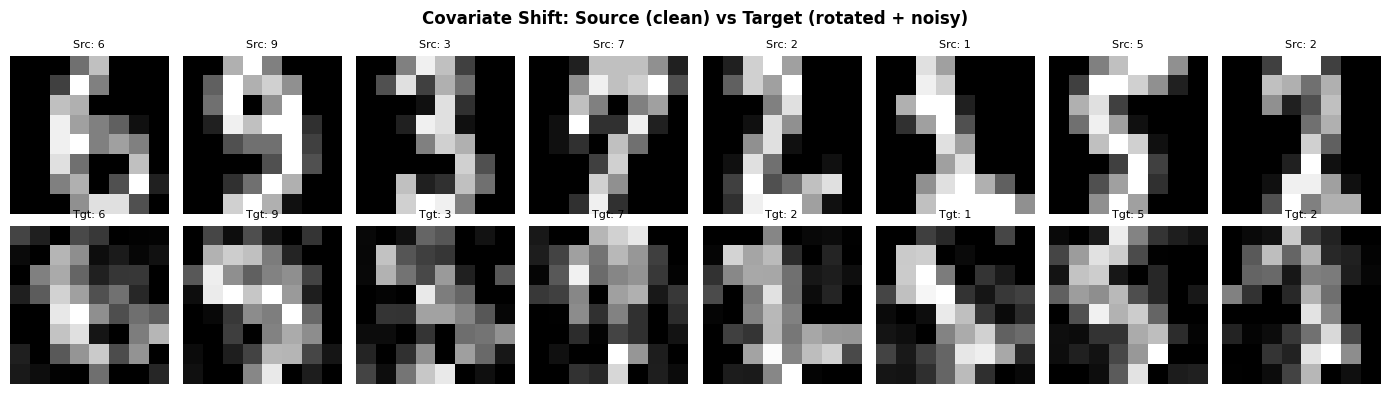

In [ ]:
# Side-by-side comparison of source and target domains
rng = np.random.RandomState(SEED)
idx = rng.choice(len(X), 8, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, j in enumerate(idx):
    axes[0, i].imshow(X[j], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f"Src: {y[j]}", fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_target[j], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f"Tgt: {y[j]}", fontsize=8)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel("Source", fontsize=10)
axes[1, 0].set_ylabel("Target", fontsize=10)
fig.suptitle("Covariate Shift: Source (clean) vs Target (rotated + noisy)", fontweight='bold')
plt.tight_layout()
plt.show()


### 2.3 Train / Val / Test Split

In [ ]:
# Split indices once — identical distributions in source and target
train_idx, test_idx = train_test_split(
    np.arange(len(X)), test_size=0.2, random_state=SEED, stratify=y)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.2, random_state=SEED, stratify=y[train_idx])

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

def make_tf_dataset(images, labels, indices, batch_size=32, shuffle=False):
    """Build a tf.data.Dataset from numpy arrays and index selection."""
    X_sub = images[indices][..., np.newaxis]  # (N, 8, 8, 1) — channel last
    y_sub = keras.utils.to_categorical(labels[indices], NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices(
        (X_sub.astype(np.float32), y_sub.astype(np.float32)))
    if shuffle:
        ds = ds.shuffle(len(indices), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Create 6 datasets (source: train/val/test  |  target: train/val/test)
ds_src_train = make_tf_dataset(X,        y, train_idx, shuffle=True)
ds_src_val   = make_tf_dataset(X,        y, val_idx,   shuffle=False)
ds_src_test  = make_tf_dataset(X,        y, test_idx,  shuffle=False)
ds_tgt_train = make_tf_dataset(X_target, y, train_idx, shuffle=True)
ds_tgt_val   = make_tf_dataset(X_target, y, val_idx,   shuffle=False)
ds_tgt_test  = make_tf_dataset(X_target, y, test_idx,  shuffle=False)

print("All 6 datasets created successfully.")


Train: 1149 | Val: 288 | Test: 360
All 6 datasets created successfully.


## Part 3 — CNN Architecture: Backbone + Head Separation

(Representation Hypothesis — Yosinski et al., 2014):
- **Early layers (backbone):** learn generic features (edges, textures) — transferable
- **Late layers (head):** learn task-specific features — need adaptation

**Architecture:**
```
Input (8, 8, 1)
  → Conv2D(32, 3, relu, same)  [backbone — conv1]
  → MaxPool2D(2)               [backbone — pool1]
  → Conv2D(64, 3, relu, same)  [backbone — conv2]
  → GlobalAveragePooling2D()   [backbone — gap]  ← feature vector (dim=64)
  → Dense(64, relu)            [head — dense1]
  → Dropout(0.3)
  → Dense(10, softmax)         [head — output]
```

**Fine-tuning objective:**
$$\min_{\theta} \; \mathcal{L}_T(\theta) + \lambda \|\theta - \theta_{\text{pretrained}}\|_2^2$$

- $\lambda \to \infty$: only head trains (Feature Extraction)
- $\lambda = 0$: unconstrained Full Fine-tuning
- $\lambda \in (0, \infty)$: controlled adaptation (L2 regularization)


### 3.1 Build Model

> **TODO:** Complete the model definition.  
> - Define the **backbone** layers (Conv2D + MaxPool + Conv2D + GAP).  
> - Set `trainable=not freeze_backbone` on backbone layers when needed.  
> - Define the **head** (Dense + Dropout + Dense) with optional L2 regularization.


In [ ]:
def build_model(freeze_backbone: bool = False,
               l2_reg: float = 0.0,
               name: str = "SmallCNN") -> keras.Model:
    """
    Small CNN with separable backbone and head.

    Args:
        freeze_backbone : if True, backbone layers are non-trainable
        l2_reg          : L2 regularization coefficient on Dense layers
        name            : model name

    Returns:
        Compiled keras.Model
    """
    inputs = keras.Input(shape=(8, 8, 1), name="input")

    # ── BACKBONE ──────────────────────────────────────────────────
    x = layers.Conv2D(32, 3, activation='relu', padding='same',
                      trainable=not freeze_backbone, name='conv1')(inputs)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same',
                      trainable=not freeze_backbone, name='conv2')(x)
    features = layers.GlobalAveragePooling2D(name='gap')(x)

    # ── HEAD ──────────────────────────────────────────────────────
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=reg, name='dense1')(features)
    x = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                           kernel_regularizer=reg, name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Sanity check
model_test = build_model()
model_test.summary()
print("\nTrainable params:", sum(np.prod(v.shape) for v in model_test.trainable_variables))


Model: "SmallCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,626 (92.29 KB)

 Trainable params: 23,626 (92.29 KB)

 Non-trainable params: 0 (0.00 B)


Trainable params: 23626


### 3.2 Weight Transfer Utility

In [ ]:
def transfer_weights(source_model: keras.Model,
                    target_model: keras.Model,
                    backbone_only: bool = False):
    """
    Copy weights from source_model to target_model.

    Args:
        source_model  : pretrained model
        target_model  : model to initialize
        backbone_only : if True, only copy backbone layers
    """
    backbone_layers = {'conv1', 'pool1', 'conv2', 'gap'}
    for layer in target_model.layers:
        if backbone_only and layer.name not in backbone_layers:
            continue
        try:
            src_w = source_model.get_layer(layer.name).get_weights()
            if src_w:
                layer.set_weights(src_w)
        except ValueError:
            pass  # layer not present in source

# Verify: transfer weights and check parameter counts
# (Will be used in Part 6 — do not call yet)
print("transfer_weights defined.")


transfer_weights defined.


## Part 4 — Source Pretraining

Train a model on the **source domain** (clean digits). Then evaluate it on both:
- **Source test** (in-domain) — expected high accuracy
- **Target test** (out-of-domain) — reveals the **domain gap**

> **TODO:** Build a fresh model, train for up to 40 epochs with EarlyStopping, evaluate on both test sets.


In [ ]:
tf.random.set_seed(SEED)

# Build and train on source domain
model_src = build_model(name="src_pretrained")
history_src = model_src.fit(
    ds_src_train,
    validation_data=ds_src_val,
    epochs=40,
    callbacks=[keras.callbacks.EarlyStopping(patience=7,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=1
)
src_test_acc = model_src.evaluate(ds_src_test, verbose=0)[1]
tgt_test_acc = model_src.evaluate(ds_tgt_test, verbose=0)[1]
print(f"Source test accuracy : {src_test_acc:.3f}")
print(f"Target test accuracy : {tgt_test_acc:.3f}  <-- domain shift gap")
print(f"Domain gap           : {src_test_acc - tgt_test_acc:.3f}")


Epoch 1/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.1323 - loss: 2.2987 - val_accuracy: 0.1736 - val_loss: 2.2888
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1775 - loss: 2.2755 - val_accuracy: 0.1597 - val_loss: 2.2478
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2594 - loss: 2.2043 - val_accuracy: 0.5000 - val_loss: 2.1049
Epoch 4/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3847 - loss: 1.9917 - val_accuracy: 0.6562 - val_loss: 1.7641
Epoch 5/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5109 - loss: 1.6545 - val_accuracy: 0.8021 - val_loss: 1.3267
Epoch 6/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5901 - loss: 1.3342 - val_accuracy: 0.7986 - val_loss: 1.0425
Epoch 7/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6684 - loss: 1.1026 - val_accuracy: 0.8333 - val_loss: 0.8494
Epoch 8/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7111 - loss: 0.9345 - val_accuracy: 0.8090 - val_l

### 4.1 Plot Training Curves

> **TODO:** Plot the train/val loss and accuracy curves from `history_src`.

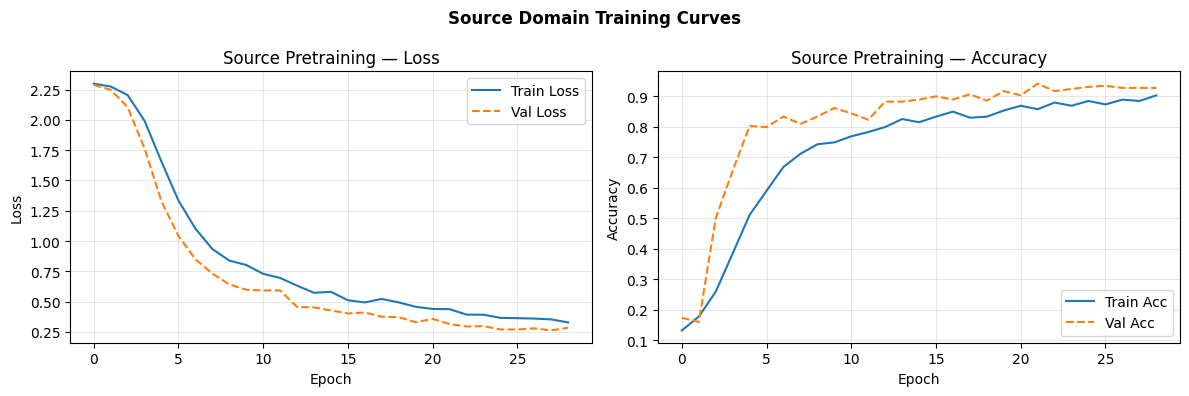

In [ ]:
# Plot training curves (loss and accuracy)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history_src.history['loss'], label='Train Loss')
axes[0].plot(history_src.history['val_loss'], label='Val Loss', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Source Pretraining — Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_src.history['accuracy'], label='Train Acc')
axes[1].plot(history_src.history['val_accuracy'], label='Val Acc', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Source Pretraining — Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Source Domain Training Curves', fontweight='bold')
plt.tight_layout()
plt.show()


## Part 5 — Target Label Budget (Few-Shot Scenario)

In real applications, **annotating target data is expensive**. We simulate this with a limited label budget.

> **TODO:** Create a stratified subset `budget_indices` of `TARGET_LABEL_BUDGET` samples from `train_idx`.  
> Build `ds_tgt_budget` from this subset.  
> Verify that classes are roughly balanced.


In [ ]:
TARGET_LABEL_BUDGET = 200  # Try also: 50, 100, 500

# Stratified sampling — pick per_class = BUDGET // NUM_CLASSES samples per class
rng = np.random.RandomState(SEED)
budget_indices = []
per_class = TARGET_LABEL_BUDGET // NUM_CLASSES
for c in np.unique(y[train_idx]):
    class_idx = train_idx[y[train_idx] == c]
    chosen = rng.choice(class_idx, min(per_class, len(class_idx)), replace=False)
    budget_indices.extend(chosen.tolist())
budget_indices = np.array(budget_indices)
ds_tgt_budget = make_tf_dataset(X_target, y, budget_indices, shuffle=True)
print(f"Budget size: {len(budget_indices)}")
unique, counts = np.unique(y[budget_indices], return_counts=True)
print("Samples per class:", dict(zip(unique, counts)))


Budget size: 200
Samples per class: {np.int64(0): np.int64(20), np.int64(1): np.int64(20), np.int64(2): np.int64(20), np.int64(3): np.int64(20), np.int64(4): np.int64(20), np.int64(5): np.int64(20), np.int64(6): np.int64(20), np.int64(7): np.int64(20), np.int64(8): np.int64(20), np.int64(9): np.int64(20)}


## Part 6 — Transfer Strategy Comparison

We implement the **four strategies** from the course strategy comparison table:

| Strategy | Backbone | Head | LR | When to use |
|---|---|---|---|---|
| A — Scratch | Random init | Random init | 1e-3 | Baseline |
| B — Feature Extraction | Frozen (source) | Retrained | 1e-3 | < 500 target samples |
| C — Gradual Unfreezing | Partially frozen | Retrained | Small (1e-4) | 500–5000 samples |
| D — Full Fine-tuning | All layers trained | Retrained | Small (1e-4) + L2 | > 5000 samples |

All strategies train on `ds_tgt_budget` and evaluate on `ds_tgt_test`.


### Strategy A — Scratch (Baseline)

> **TODO:** Train a fresh model (no pretrained weights) on `ds_tgt_budget` for up to 80 epochs.

In [ ]:
tf.random.set_seed(SEED)

# Strategy A — build fresh model, train on ds_tgt_budget
model_scratch = build_model(name="scratch")
model_scratch.fit(
    ds_tgt_budget,
    validation_data=ds_tgt_val,
    epochs=80,
    callbacks=[keras.callbacks.EarlyStopping(patience=10,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=0
)
acc_scratch = model_scratch.evaluate(ds_tgt_test, verbose=0)[1]
print(f"[A] Scratch — Target Test Acc: {acc_scratch:.3f}")


[A] Scratch — Target Test Acc: 0.731


### Strategy B — Feature Extraction (Frozen Backbone)

The backbone acts as a **fixed feature extractor**. Only the head is trained.
This corresponds to $\lambda \to \infty$ in the fine-tuning objective.

> **TODO:**  
> 1. Build a model with `freeze_backbone=True`.  
> 2. Transfer backbone weights from `model_src`.  
> 3. Verify that only head parameters are trainable.  
> 4. Train on `ds_tgt_budget`.


In [ ]:
tf.random.set_seed(SEED)

# Strategy B — frozen backbone, train head only
model_fe = build_model(freeze_backbone=True, name="feature_extraction")
transfer_weights(model_src, model_fe, backbone_only=False)

# Verify: count trainable params — should be head only
n_trainable = sum(np.prod(v.shape) for v in model_fe.trainable_variables)
n_total     = sum(np.prod(v.shape) for v in model_fe.variables)
print(f"Trainable: {n_trainable} / {n_total} ({100*n_trainable/n_total:.1f}%)")

model_fe.fit(
    ds_tgt_budget,
    validation_data=ds_tgt_val,
    epochs=80,
    callbacks=[keras.callbacks.EarlyStopping(patience=10,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=0
)
acc_feature_ext = model_fe.evaluate(ds_tgt_test, verbose=0)[1]
print(f"[B] Feature Extraction — Target Test Acc: {acc_feature_ext:.3f}")


Trainable: 4810 / 23628 (20.4%)
[B] Feature Extraction — Target Test Acc: 0.747


### Strategy C — Gradual Unfreezing (Discriminative LR)

1. **Phase 1:** Freeze backbone, warm up the head with a high learning rate.
2. **Phase 2:** Unfreeze the last conv block with a smaller learning rate.

This implements the **discriminative learning rate** principle:  
$$\eta_l = \frac{\eta_{\text{base}}}{\gamma^{L-l}}, \quad \gamma = 2.6$$

> **TODO:**  
> 1. Transfer ALL weights from `model_src`.  
> 2. Phase 1: Freeze backbone, train head for 15 epochs with `lr=1e-3`.  
> 3. Phase 2: Unfreeze `conv2`/`gap`, recompile with `lr=1e-3/2.6`, train 30 more epochs.

GAP = Global Average Pooling — c'est une couche de pooling qui remplace les couches Flatten + Dense traditionnelles à la fin d'un CNN. Au lieu de "aplatir" toute la feature map en un long vecteur, GAP calcule simplement la moyenne de chaque feature map entière en un seul scalaire.


In [ ]:
tf.random.set_seed(SEED)

# Discriminative LR schedule
BASE_LR = 1e-3
GAMMA   = 2.6
lr_head    = BASE_LR             # 1e-3  — head (largest)
lr_conv2   = BASE_LR / GAMMA     # ~3.8e-4 — last conv block
lr_conv1   = BASE_LR / GAMMA**2  # ~1.5e-4 — first conv block (smallest)

print("Discriminative LR Schedule:")
print(f"  conv1 / pool1 : {lr_conv1:.2e}")
print(f"  conv2 / gap   : {lr_conv2:.2e}")
print(f"  head          : {lr_head:.2e}")

# Strategy C — Gradual Unfreezing
model_gradual = build_model(name="gradual_unfreeze")
transfer_weights(model_src, model_gradual, backbone_only=False)

# Phase 1: freeze backbone, warm up head
for layer_name in ['conv1', 'pool1', 'conv2', 'gap']:
    model_gradual.get_layer(layer_name).trainable = False
model_gradual.compile(
    optimizer=keras.optimizers.Adam(lr_head),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_gradual.fit(ds_tgt_budget, epochs=15, verbose=0)

# Phase 2: unfreeze conv2 + gap, use smaller LR
for layer_name in ['conv2', 'gap']:
    model_gradual.get_layer(layer_name).trainable = True
model_gradual.compile(
    optimizer=keras.optimizers.Adam(lr_conv2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_gradual.fit(
    ds_tgt_budget,
    validation_data=ds_tgt_val,
    epochs=30,
    callbacks=[keras.callbacks.EarlyStopping(patience=10,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=0
)
acc_gradual = model_gradual.evaluate(ds_tgt_test, verbose=0)[1]
print(f"[C] Gradual Unfreeze — Target Test Acc: {acc_gradual:.3f}")


Discriminative LR Schedule:
  conv1 / pool1 : 1.48e-04
  conv2 / gap   : 3.85e-04
  head          : 1.00e-03
[C] Gradual Unfreeze — Target Test Acc: 0.783


### Strategy D — Full Fine-tuning

All layers are updated. L2 regularization is used to prevent catastrophic forgetting:
$$\min_{\theta} \; \mathcal{L}_T(\theta) + \lambda \|\theta - \theta_{\text{pretrained}}\|_2^2$$

> **Note (from course):** This L2 regularization is structurally identical to **EWC** (Week 5)!  
> Both anchor weights near a previous solution to prevent forgetting prior knowledge.

> **TODO:**  
> 1. Build a model with `l2_reg=1e-3`.  
> 2. Transfer ALL weights from `model_src`.  
> 3. Compile with a small learning rate (`1e-4`) and train on `ds_tgt_budget`.


In [ ]:
tf.random.set_seed(SEED)

# Strategy D — full fine-tuning with L2 regularization
model_full = build_model(l2_reg=1e-3, name="full_finetune")
transfer_weights(model_src, model_full, backbone_only=False)
model_full.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_full.fit(
    ds_tgt_budget,
    validation_data=ds_tgt_val,
    epochs=60,
    callbacks=[keras.callbacks.EarlyStopping(patience=10,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=0
)
acc_full_ft = model_full.evaluate(ds_tgt_test, verbose=0)[1]
print(f"[D] Full Fine-tuning — Target Test Acc: {acc_full_ft:.3f}")


[D] Full Fine-tuning — Target Test Acc: 0.725


## Part 7 — Comparison & Visualization

> **TODO:** Assemble all results into a bar chart comparing the strategies.  
> Also display the confusion matrix for the best-performing strategy.


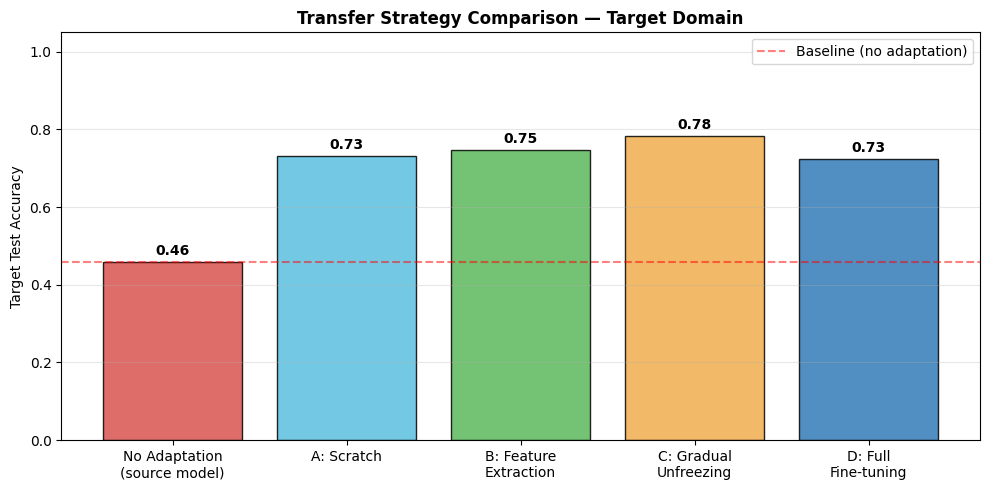


=== Strategy Comparison Summary ===
  No Adaptation (source model)  : 0.458
  A: Scratch                    : 0.731
  B: Feature Extraction         : 0.747
  C: Gradual Unfreezing         : 0.783
  D: Full Fine-tuning           : 0.725


In [ ]:
# Comparison bar chart
results = {
    "No Adaptation\n(source model)": tgt_test_acc,
    "A: Scratch": acc_scratch,
    "B: Feature\nExtraction": acc_feature_ext,
    "C: Gradual\nUnfreezing": acc_gradual,
    "D: Full\nFine-tuning": acc_full_ft,
}
colors = ['#d9534f', '#5bc0de', '#5cb85c', '#f0ad4e', '#337ab7']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results.keys(), results.values(), color=colors, edgecolor='black', alpha=0.85)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Target Test Accuracy")
ax.set_title("Transfer Strategy Comparison — Target Domain", fontweight='bold')
ax.axhline(y=tgt_test_acc, color='red', linestyle='--', alpha=0.5, label='Baseline (no adaptation)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print("\n=== Strategy Comparison Summary ===")
for name, acc in results.items():
    print(f"  {name.replace(chr(10), ' '):30s}: {acc:.3f}")


Best strategy: C: Gradual Unfreezing (acc=0.783)


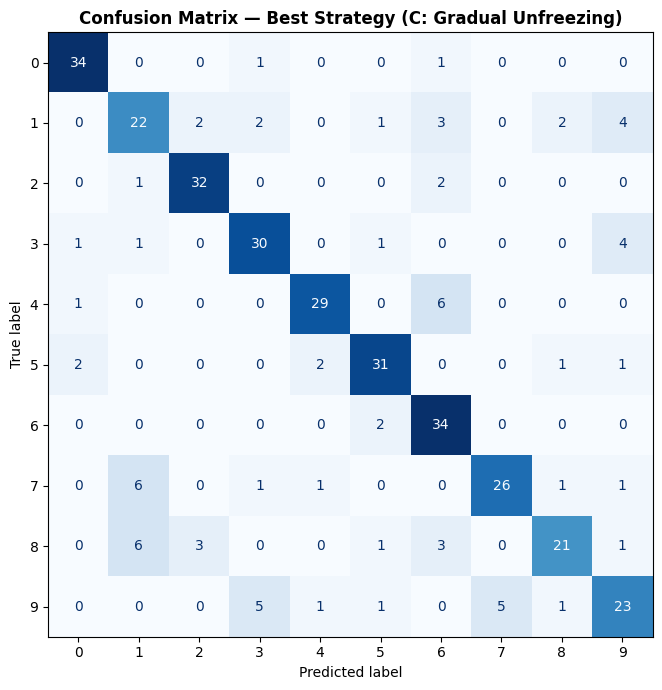

In [ ]:
# Confusion matrix for the best strategy
best_model = max(
    [('A: Scratch', model_scratch, acc_scratch),
     ('B: Feature Extraction', model_fe, acc_feature_ext),
     ('C: Gradual Unfreezing', model_gradual, acc_gradual),
     ('D: Full Fine-tuning', model_full, acc_full_ft)],
    key=lambda t: t[2]
)
best_name, best_model_obj, best_acc = best_model
print(f"Best strategy: {best_name} (acc={best_acc:.3f})")

y_pred, y_true = [], []
for xb, yb in ds_tgt_test:
    preds = best_model_obj.predict(xb, verbose=0).argmax(axis=1)
    y_pred.extend(preds.tolist())
    y_true.extend(yb.numpy().argmax(axis=1).tolist())
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix — Best Strategy ({best_name})", fontweight='bold')
plt.tight_layout()
plt.show()


## Part 8 — Critical Analysis

Answer the following questions in a markdown cell below each question.



**Question 1:** Which strategy performed best under the label budget of 200 samples? Why?

*Your answer:*

Strategy C (Gradual Unfreezing) performed best with **0.783** test accuracy on the target domain.

With only 200 samples, training from scratch (A: 0.731) is data-starved. Feature Extraction (B: 0.747) helps by reusing the pretrained backbone, but the frozen features can't adapt to the rotated/noisy domain. Full Fine-tuning (D: 0.725) does *worse* than scratch, updating all 23K parameters on 200 samples causes overfitting despite L2 regularization.

Gradual Unfreezing wins because it combines both advantages: Phase 1 warms up the head safely with the backbone frozen, then Phase 2 lets the upper conv layers adapt with a small discriminative LR (3.85e-4), refining representations without destroying source knowledge.


**Question 2:** The course lists "wrong learning rate" as a common pitfall. What would happen if you used `lr=1e-3` for Full Fine-tuning instead of `lr=1e-4`?

*Your answer:*

It would cause **catastrophic forgetting**. Steps 10× larger would rapidly overwrite the pretrained backbone weights before the head stabilizes on the target task. The model would effectively re-learn from scratch on 200 samples — equivalent to Strategy A (0.731). Strategy D with the correct `lr=1e-4` already underperforms at 0.725; a wrong learning rate would make it worse still.



**Question 3:** The L2 regularization in Strategy D is structurally identical to EWC. What is the key difference between EWC and simple L2?

*Your answer:*

Both penalize deviation from pretrained weights: $\lambda \|\theta - \theta_\text{old}\|^2$. The difference is how the penalty is distributed:

- **Simple L2**: uniform penalty — every weight is treated equally regardless of importance.
- **EWC**: weights the penalty by the **Fisher Information Matrix** — $\sum_i F_i(\theta_i - \theta_{\text{old},i})^2$ — critical weights are penalized heavily, unimportant ones are free to adapt.

L2 is isotropic; EWC is importance-weighted.



**Question 4:** According to the Ben-David bound, transfer works well when three conditions are met. Name them and link each to what you observed.

*Your answer:*
The bound: $\varepsilon_T \leq \varepsilon_S + d_{\mathcal{H}\Delta\mathcal{H}}(\mathcal{D}_S, \mathcal{D}_T) + \lambda^*$

1. **Low source error ($\varepsilon_S$ small):** The source model achieved high accuracy on clean digits. This is the prerequisite, without a well-trained source model, strategies B/C/D have nothing useful to transfer.

2. **Small domain divergence ($d_{\mathcal{H}\Delta\mathcal{H}}$ small):** The no-adaptation baseline dropped to **0.458** on the target, confirming a real but moderate gap. The gap was bridgeable, all strategies recovered significantly above baseline, with C reaching 0.783. A more severe shift would widen this term and limit recovery.

3. **Shared ideal hypothesis ($\lambda^*$ small):** Source and target share the same 10 digit classes,  only acquisition conditions differ. The conv features (edges, curves) trained on clean digits remain informative for rotated/noisy ones, confirming a single hypothesis can perform well on both domains.


## Challenge — Medical Imaging Application

This challenge applies transfer learning to a real medical imaging task using the **MedMNIST** benchmark (Chest X-ray / Pneumonia detection).

**Setup:**
```bash
pip install medmnist
```

**Dataset:** PneumoniaMNIST — chest X-rays, binary classification: Normal vs. Pneumonia  
(based on Kaggle Chest X-ray Images dataset, resized to 28x28)


- Source: digits (abundant, fast to train — proxy for ImageNet)
- Target: medical X-rays (few samples, different domain)

### Objective
Implement at least ONE of the following:
1. **Challenge A:** Use a pretrained backbone (trained on digits) and adapt it to PneumoniaMNIST via Feature Extraction.
2. **Challenge B:** Compare Feature Extraction vs Full Fine-tuning on PneumoniaMNIST with a budget of 200 labeled samples.


In [ ]:
# Install MedMNIST (run once)
!pip install medmnist -q

import medmnist
from medmnist import PneumoniaMNIST

# Load PneumoniaMNIST
download = True
train_dataset = PneumoniaMNIST(split='train', download=download, size=28)
val_dataset   = PneumoniaMNIST(split='val',   download=download, size=28)
test_dataset  = PneumoniaMNIST(split='test',  download=download, size=28)

# Inspect
print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00


100%|██████████| 4.17M/4.17M [00:00<00:00, 4.36MB/s]

Train samples: 4708
Test samples : 624


X_med_train: (4708, 28, 28) — classes: [0 1]


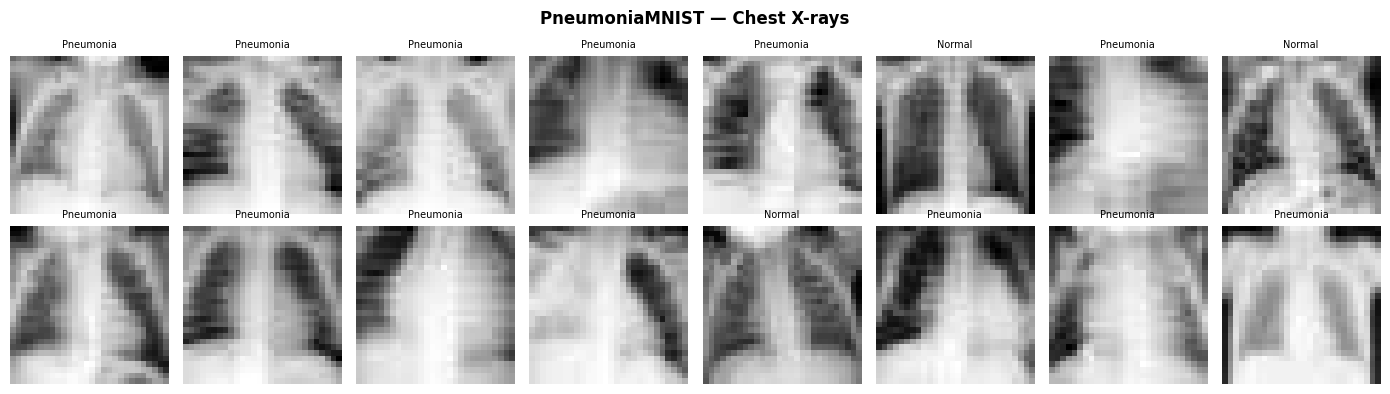

In [ ]:
# Helper: convert MedMNIST to tf.data.Dataset
def medmnist_to_numpy(dataset):
    X = np.array([np.array(item[0]) for item in dataset], dtype=np.float32) / 255.0
    y = np.array([item[1][0] for item in dataset], dtype=np.int64)
    return X, y

X_med_train, y_med_train = medmnist_to_numpy(train_dataset)
X_med_val,   y_med_val   = medmnist_to_numpy(val_dataset)
X_med_test,  y_med_test  = medmnist_to_numpy(test_dataset)

print(f"X_med_train: {X_med_train.shape} — classes: {np.unique(y_med_train)}")

# Visualize a few samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
label_names = ['Normal', 'Pneumonia']
for i in range(8):
    axes[0, i].imshow(X_med_train[i], cmap='gray')
    axes[0, i].set_title(label_names[y_med_train[i]], fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_med_train[i + 100], cmap='gray')
    axes[1, i].set_title(label_names[y_med_train[i + 100]], fontsize=7)
    axes[1, i].axis('off')
fig.suptitle("PneumoniaMNIST — Chest X-rays", fontweight='bold')
plt.tight_layout()
plt.show()


### Challenge Implementation

> **TODO:** Implement your chosen challenge.  
>
> **Hints for adapting the backbone to 28x28 inputs:**
> - The backbone was trained on 8x8 images. For 28x28, adjust the CNN architecture.
> - Use `build_model_medical()` (define a new function) with `input_shape=(28, 28, 1)` and 2 classes.
> - Transfer the `conv1` and `conv2` weights from `model_src` (they are shape-compatible if you keep the same filter sizes).
> - Use `backbone_only=True` in `transfer_weights`.


Medical budget: 200 samples

--- Challenge A: Feature Extraction ---
Trainable: 4290 / 23492 (18.3%)
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.5250 - loss: 0.8685 - val_accuracy: 0.7424 - val_loss: 0.6072
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5000 - loss: 0.8758 - val_accuracy: 0.2576 - val_loss: 0.7852
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.4700 - loss: 0.9061 - val_accuracy: 0.2576 - val_loss: 0.7643
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.5350 - loss: 0.7763 - val_accuracy: 0.7863 - val_loss: 0.6396
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.5500 - loss: 0.7167 - val_accuracy: 0.7786 - val_loss: 0.6235
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5450 - loss: 0.6813 - val_accuracy: 0.7863 - val_loss: 0.6296
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6200 - loss: 0.6508 - val_accuracy: 0.7576 - val_loss: 0.6370
Epoch 8/30
7/7 ━━━━━━

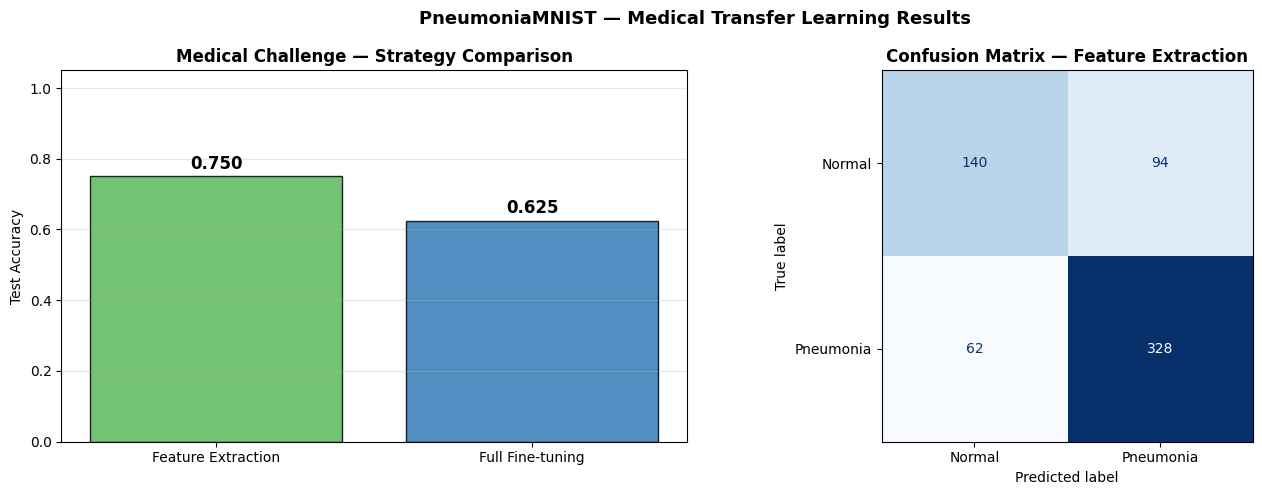


Best medical strategy: Feature Extraction (acc=0.750)


In [ ]:
# Install MedMNIST if not available
# !pip install medmnist -q

NUM_CLASSES_MED = 2  # Normal vs Pneumonia

def build_model_medical(freeze_backbone: bool = False, name: str = "MedCNN") -> keras.Model:
    """
    CNN for 28x28 medical images with 2 output classes.
    Shares the same conv layer names ('conv1', 'conv2') as build_model
    so transfer_weights can copy filters directly.
    """
    inputs = keras.Input(shape=(28, 28, 1), name="input")

    # ── BACKBONE (same filter sizes → weights are compatible) ────
    x = layers.Conv2D(32, 3, activation='relu', padding='same',
                      trainable=not freeze_backbone, name='conv1')(inputs)
    x = layers.BatchNormalization(trainable=not freeze_backbone, name='bn1')(x)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same',
                      trainable=not freeze_backbone, name='conv2')(x)
    x = layers.BatchNormalization(trainable=not freeze_backbone, name='bn2')(x)
    x = layers.MaxPooling2D(2, name='pool2')(x)
    features = layers.GlobalAveragePooling2D(name='gap')(x)

    # ── HEAD ────────────────────────────────────────────────────
    x = layers.Dense(64, activation='relu', name='dense1')(features)
    x = layers.Dropout(0.4, name='dropout')(x)
    outputs = layers.Dense(NUM_CLASSES_MED, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Load and prepare medical data ───────────────────────────────────────────
def make_med_dataset(X_med, y_med, batch_size=32, shuffle=False):
    X_ch = X_med[..., np.newaxis] if X_med.ndim == 3 else X_med  # ensure (N,H,W,1)
    ds = tf.data.Dataset.from_tensor_slices(
        (X_ch.astype(np.float32), y_med.astype(np.int64)))
    if shuffle:
        ds = ds.shuffle(len(y_med), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Full datasets
ds_med_train_full = make_med_dataset(X_med_train, y_med_train, shuffle=True)
ds_med_val        = make_med_dataset(X_med_val,   y_med_val)
ds_med_test       = make_med_dataset(X_med_test,  y_med_test)

# Label budget of 200 samples (stratified)
rng_med = np.random.RandomState(SEED)
med_budget_indices = []
for c in np.unique(y_med_train):
    c_idx = np.where(y_med_train == c)[0]
    chosen = rng_med.choice(c_idx, min(100, len(c_idx)), replace=False)  # 100 per class
    med_budget_indices.extend(chosen.tolist())
med_budget_indices = np.array(med_budget_indices)
ds_med_budget = make_med_dataset(
    X_med_train[med_budget_indices], y_med_train[med_budget_indices], shuffle=True)
print(f"Medical budget: {len(med_budget_indices)} samples")

# ── Challenge A: Feature Extraction on PneumoniaMNIST ───────────────────────
tf.random.set_seed(SEED)
print("\n--- Challenge A: Feature Extraction ---")
model_med_fe = build_model_medical(freeze_backbone=True, name="med_feature_extraction")
# Transfer conv1 and conv2 weights from model_src (backbone_only=True)
transfer_weights(model_src, model_med_fe, backbone_only=True)

n_trainable = sum(np.prod(v.shape) for v in model_med_fe.trainable_variables)
n_total = sum(np.prod(v.shape) for v in model_med_fe.variables)
print(f"Trainable: {n_trainable} / {n_total} ({100*n_trainable/n_total:.1f}%)")

model_med_fe.fit(
    ds_med_budget,
    validation_data=ds_med_val,
    epochs=30,
    callbacks=[keras.callbacks.EarlyStopping(patience=7,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=1
)
acc_med_fe = model_med_fe.evaluate(ds_med_test, verbose=0)[1]
print(f"[Challenge A] Feature Extraction — Medical Test Acc: {acc_med_fe:.3f}")

# ── Challenge B: Full Fine-tuning on PneumoniaMNIST ──────────────────────────
tf.random.set_seed(SEED)
print("\n--- Challenge B: Full Fine-tuning ---")
model_med_full = build_model_medical(freeze_backbone=False, name="med_full_finetune")
transfer_weights(model_src, model_med_full, backbone_only=True)
model_med_full.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_med_full.fit(
    ds_med_budget,
    validation_data=ds_med_val,
    epochs=40,
    callbacks=[keras.callbacks.EarlyStopping(patience=7,
               restore_best_weights=True, monitor='val_accuracy')],
    verbose=1
)
acc_med_full = model_med_full.evaluate(ds_med_test, verbose=0)[1]
print(f"[Challenge B] Full Fine-tuning — Medical Test Acc: {acc_med_full:.3f}")

# ── Comparison bar chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
strats = ['Feature Extraction', 'Full Fine-tuning']
accs   = [acc_med_fe, acc_med_full]
colors = ['#5cb85c', '#337ab7']
bars = axes[0].bar(strats, accs, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Medical Challenge — Strategy Comparison', fontweight='bold')
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)

# Confusion matrix for best medical model
best_med = model_med_fe if acc_med_fe >= acc_med_full else model_med_full
best_med_name = 'Feature Extraction' if acc_med_fe >= acc_med_full else 'Full Fine-tuning'
y_pred_med, y_true_med = [], []
for xb, yb in ds_med_test:
    preds = best_med.predict(xb, verbose=0).argmax(axis=1)
    y_pred_med.extend(preds.tolist())
    y_true_med.extend(yb.numpy().tolist())
cm_med = confusion_matrix(y_true_med, y_pred_med)
disp_med = ConfusionMatrixDisplay(cm_med, display_labels=['Normal', 'Pneumonia'])
disp_med.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Confusion Matrix — {best_med_name}', fontweight='bold')

plt.suptitle('PneumoniaMNIST — Medical Transfer Learning Results', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBest medical strategy: {best_med_name} (acc={max(acc_med_fe, acc_med_full):.3f})")
